# 02 · SIFT Keypoints & Match Verification

**Goal:** detect SIFT keypoints on tree-masked frames, find a pair of frames
with enough matchable correspondences, RANSAC-verify, and cache them so
notebook 03's from-scratch two-view reconstruction has clean inputs.

### Why this notebook does mask preprocessing

cv2's default SIFT + Lowe ratio + cross-check on raw skyward frames returns
0 matches between frames because the canopy/sky feature space is overwhelming.
We apply the same CLAHE + tree-color mask preprocessing as notebook 04 so
SIFT only sees bark/branch pixels, then loosen the matcher (ratio=0.92,
no cross-check) to compensate for the now-smaller descriptor pool.

Library-wrapped (cv2.SIFT, cv2.findEssentialMat) — geometry from scratch
lives in `03_two_view_scratch.ipynb`.


In [1]:
# Standard preamble — every notebook seeds np.random.seed(131).
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
np.random.seed(131)

import matplotlib.pyplot as plt
%matplotlib inline


## 0. Configuration

Set `TREE_ID` to your capture. Reuses `<TREE_ID>_clahe/` and
`<TREE_ID>_masked/` frame dirs if they were already produced by notebook 04,
so don't re-run that work.


In [2]:
from src import calibration, features, viz
import cv2
import numpy as np

TREE_ID = "tree_5"   # change me per capture

RAW_FRAMES_DIR    = PROJECT_ROOT / "data" / "frames" / TREE_ID
CLAHE_FRAMES_DIR  = PROJECT_ROOT / "data" / "frames" / f"{TREE_ID}_clahe"
MASKED_FRAMES_DIR = PROJECT_ROOT / "data" / "frames" / f"{TREE_ID}_masked"
K_PATH            = PROJECT_ROOT / "data" / "calibration" / "intrinsics.npz"

if not RAW_FRAMES_DIR.exists():
    raise FileNotFoundError(
        f"Raw frames not found at {RAW_FRAMES_DIR}.\n"
        "Run notebook 01 first to extract frames for this tree."
    )
if not K_PATH.exists():
    raise FileNotFoundError(
        f"Camera intrinsics not found at {K_PATH}.\n"
        "Run notebook 01 first to calibrate the camera."
    )

intrinsics = calibration.CameraIntrinsics.load(K_PATH)
raw_frames = sorted(RAW_FRAMES_DIR.glob("frame_*.png"))
print(f"Tree: {TREE_ID}   raw frames: {len(raw_frames)}   K loaded (RMS={intrinsics.rms:.3f} px)")


Tree: tree_5   raw frames: 80   K loaded (RMS=1.821 px)


## 1. CLAHE preprocessing

Skipped if the CLAHE dir is already populated (e.g., from running notebook 04).


In [3]:
CLAHE_FRAMES_DIR.mkdir(parents=True, exist_ok=True)
if len(list(CLAHE_FRAMES_DIR.glob("frame_*.png"))) < len(raw_frames):
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    for p in raw_frames:
        img = cv2.imread(str(p))
        lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        lab[:, :, 0] = clahe.apply(lab[:, :, 0])
        cv2.imwrite(str(CLAHE_FRAMES_DIR / p.name),
                     cv2.cvtColor(lab, cv2.COLOR_LAB2BGR))
    print(f"Wrote {len(raw_frames)} CLAHE-enhanced frames to {CLAHE_FRAMES_DIR}")
else:
    print(f"Reusing existing CLAHE frames in {CLAHE_FRAMES_DIR}")


Reusing existing CLAHE frames in /Users/colevanhersett/Developer/uni/CS_131/final_proj/data/frames/tree_5_clahe


## 2. Tree-color mask — preview on one frame

Multi-point grid sampling (8 positions across the frame) — adapts to wherever
the trunk drifted in image space as the camera orbited. Only samples whose
median hue falls in the brown range get used, so misses on sky/concrete are
automatically discarded.


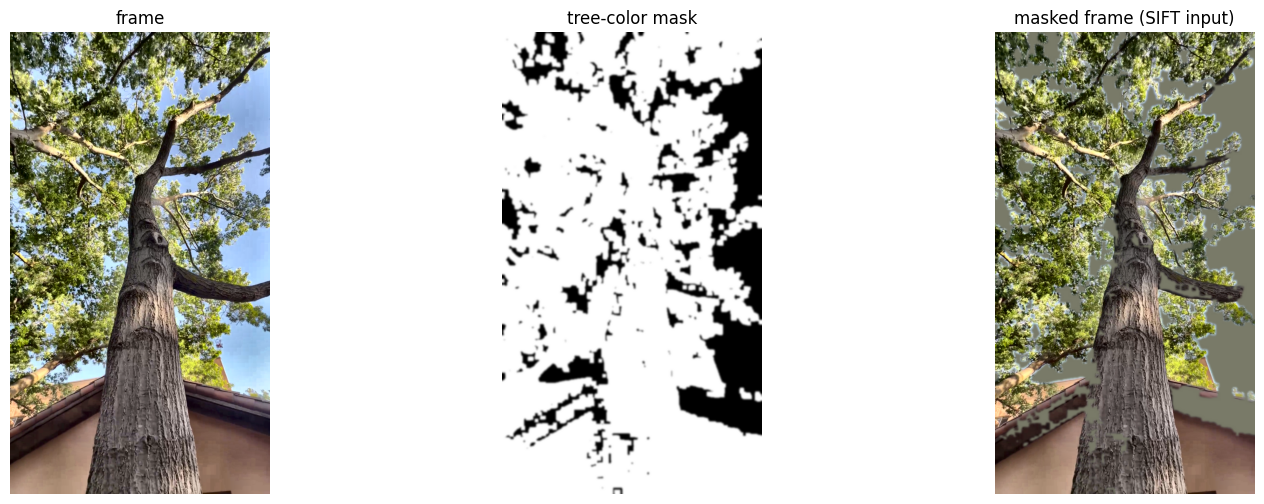

In [4]:
def tree_color_mask(img_bgr,
                    sample_grid=((0.3, 0.85), (0.5, 0.85), (0.7, 0.85),
                                 (0.3, 0.60), (0.5, 0.60), (0.7, 0.60),
                                 (0.4, 0.35), (0.6, 0.35)),
                    sample_half=20,
                    hue_tol=15,
                    feather_px=21,
                    brown_hue_range=(5, 35),
                    min_saturation=15):
    h, w = img_bgr.shape[:2]
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    combined = np.zeros((h, w), dtype=np.uint8)
    n_used = 0
    for sx, sy in sample_grid:
        cx, cy = int(w * sx), int(h * sy)
        s = sample_half
        patch = img_hsv[max(0, cy-s):cy+s, max(0, cx-s):cx+s]
        if patch.size == 0:
            continue
        h_med = int(np.median(patch[:, :, 0]))
        s_med = int(np.median(patch[:, :, 1]))
        if not (brown_hue_range[0] <= h_med <= brown_hue_range[1]):
            continue
        if s_med < min_saturation:
            continue
        n_used += 1
        lo = np.array([max(0,   h_med - hue_tol), 0, 0])
        hi = np.array([min(179, h_med + hue_tol), 255, 255])
        combined |= cv2.inRange(img_hsv, lo, hi)

    if n_used == 0:
        lo = np.array([brown_hue_range[0], min_saturation, 0])
        hi = np.array([brown_hue_range[1], 255, 255])
        combined = cv2.inRange(img_hsv, lo, hi)

    k = cv2.getStructuringElement(cv2.MORPH_RECT, (7, 7))
    combined = cv2.morphologyEx(combined, cv2.MORPH_OPEN,  k)
    combined = cv2.morphologyEx(combined, cv2.MORPH_CLOSE, k)
    combined = cv2.dilate(combined, cv2.getStructuringElement(cv2.MORPH_RECT, (9, 9)))
    return cv2.GaussianBlur(combined.astype(np.float32) / 255.0,
                            (feather_px, feather_px), 0)


def apply_mask(img_bgr, mask_float):
    fill = np.full_like(img_bgr, np.mean(img_bgr, axis=(0, 1)).astype(np.uint8))
    m = mask_float[:, :, None]
    return (img_bgr * m + fill * (1 - m)).astype(np.uint8)


# Preview on a middle frame.
clahe_frames = sorted(CLAHE_FRAMES_DIR.glob("frame_*.png"))
sample = cv2.imread(str(clahe_frames[len(clahe_frames) // 2]))
m_preview = tree_color_mask(sample)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(cv2.cvtColor(sample, cv2.COLOR_BGR2RGB));                       axes[0].set_title("frame")
axes[1].imshow(m_preview, cmap="gray", vmin=0, vmax=1);                        axes[1].set_title("tree-color mask")
axes[2].imshow(cv2.cvtColor(apply_mask(sample, m_preview), cv2.COLOR_BGR2RGB)); axes[2].set_title("masked frame (SIFT input)")
for a in axes: a.axis("off")
plt.show()


## 3. Apply mask to all frames

Skipped if the masked dir is already populated (e.g., from running notebook 04).


In [5]:
MASKED_FRAMES_DIR.mkdir(parents=True, exist_ok=True)
if len(list(MASKED_FRAMES_DIR.glob("frame_*.png"))) < len(clahe_frames):
    for p in clahe_frames:
        img = cv2.imread(str(p))
        cv2.imwrite(str(MASKED_FRAMES_DIR / p.name),
                     apply_mask(img, tree_color_mask(img)))
    print(f"Wrote {len(clahe_frames)} masked frames to {MASKED_FRAMES_DIR}")
else:
    print(f"Reusing existing masked frames in {MASKED_FRAMES_DIR}")

frame_paths = sorted(CLAHE_FRAMES_DIR.glob("frame_*.png"))
print(f"Using {len(frame_paths)} masked frames for matching")


Reusing existing masked frames in /Users/colevanhersett/Developer/uni/CS_131/final_proj/data/frames/tree_5_masked
Using 80 masked frames for matching


## 4. Loose matcher for masked frames

cv2's default `match_pair` is too strict for masked frames — Lowe ratio 0.75
+ cross-check throws away almost everything because masked frames have small
descriptor pools. We loosen ratio to 0.92, drop cross-check, and let
geometric RANSAC verification do the heavy filtering instead.


In [6]:
def match_pair_loose(path_a, path_b, K,
                      ratio=0.92, threshold_px=2.0,
                      max_features=8000, sigma=2.0,
                      min_matches=8, verbose=True):
    """SIFT + permissive Lowe + RANSAC. Returns (feats_a, feats_b, PairMatches)."""
    def detect(path):
        img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
        sift = cv2.SIFT_create(nfeatures=max_features, sigma=sigma)
        kps, desc = sift.detectAndCompute(img, None)
        if desc is None:
            desc = np.zeros((0, 128), dtype=np.float32)
        return features.FrameFeatures(image_path=path, keypoints=list(kps), descriptors=desc)

    fa = detect(path_a)
    fb = detect(path_b)
    if verbose:
        print(f"keypoints: A={len(fa.keypoints)}  B={len(fb.keypoints)}")

    bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)
    knn = bf.knnMatch(fa.descriptors, fb.descriptors, k=2)
    matches = [m for m, n in knn if m.distance < ratio * n.distance]
    if verbose:
        print(f"loose-Lowe matches: {len(matches)}")

    if len(matches) < min_matches:
        raise RuntimeError(f"Only {len(matches)} matches — too few to verify")

    pts1, pts2 = features.matches_to_arrays(fa, fb, matches)
    pair = features.verify_pair_ransac(pts1, pts2, K=K, threshold_px=threshold_px)
    if verbose:
        print(f"RANSAC inliers: {int(pair.inlier_mask.sum())}/{len(pts1)}")
    return fa, fb, pair


## 5. Auto-pick a workable frame pair

Scan small-to-medium offsets from frame 0 to find the largest pair that
still has enough RANSAC inliers. Bigger offset = wider baseline = better
two-view geometry, but mask drift between distant frames kills matching.
We pick the sweet spot automatically.


In [7]:
IDX_A = 0
candidate_offsets = [3, 5, 8, 12, 15, 20]
MIN_INLIERS = 15   # lower = more permissive; raise if you want stronger pairs

best = None   # (offset, n_inliers, feats_a, feats_b, pair)
for offset in candidate_offsets:
    if offset >= len(frame_paths):
        break
    try:
        print(f"\n--- trying offset {offset} ---")
        fa, fb, pair = match_pair_loose(
            frame_paths[IDX_A], frame_paths[offset], K=intrinsics.K,
        )
        n_inliers = int(pair.inlier_mask.sum())
        if n_inliers >= MIN_INLIERS:
            # Prefer wider baselines; keep updating as we find larger workable offsets.
            best = (offset, n_inliers, fa, fb, pair)
    except RuntimeError as e:
        print(f"  skip: {e}")

if best is None:
    raise RuntimeError(
        f"No frame pair from frame {IDX_A} has >={MIN_INLIERS} RANSAC inliers. "
        "Either the mask is too restrictive or the capture is unrecoverable."
    )

IDX_B, n_inliers, feats_a, feats_b, pair = best
print(f"\n=== Selected IDX_A={IDX_A}, IDX_B={IDX_B} ({n_inliers} inliers) ===")



--- trying offset 3 ---
keypoints: A=8000  B=8000
loose-Lowe matches: 2639
RANSAC inliers: 1472/2639

--- trying offset 5 ---
keypoints: A=8000  B=8000
loose-Lowe matches: 1975
RANSAC inliers: 733/1975

--- trying offset 8 ---
keypoints: A=8000  B=8000
loose-Lowe matches: 1569
RANSAC inliers: 287/1569

--- trying offset 12 ---
keypoints: A=8000  B=8000
loose-Lowe matches: 1411
RANSAC inliers: 92/1411

--- trying offset 15 ---
keypoints: A=8000  B=8000
loose-Lowe matches: 1314
RANSAC inliers: 68/1314

--- trying offset 20 ---
keypoints: A=8000  B=8000
loose-Lowe matches: 1307
RANSAC inliers: 26/1307

=== Selected IDX_A=0, IDX_B=20 (26 inliers) ===


## 6. Visualize the matches

Green = RANSAC inliers (geometrically consistent), red = outliers.
A healthy pair shows a clean fan of green; lots of red means the inlier
selection was poor.


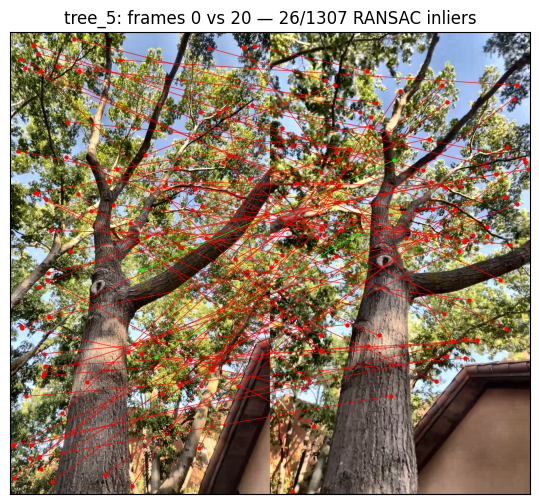

In [8]:
img_a = cv2.imread(str(frame_paths[IDX_A]))
img_b = cv2.imread(str(frame_paths[IDX_B]))
fig = viz.plot_matches(
    img_a, img_b, pair.pts1, pair.pts2, pair.inlier_mask,
    title=f"{TREE_ID}: frames {IDX_A} vs {IDX_B} — {n_inliers}/{len(pair.pts1)} RANSAC inliers",
)
viz.save_fig(fig, f"02_{TREE_ID}_matches.png")
plt.show()


## 7. Cache the inlier correspondences for notebook 03

Notebook 03 auto-discovers any `<TREE_ID>_pair_<A>_<B>.npz` in the
reconstructions directory and uses it as the input to the from-scratch
two-view pipeline.


In [9]:
cache_path = PROJECT_ROOT / "outputs" / "reconstructions" / f"{TREE_ID}_pair_{IDX_A}_{IDX_B}.npz"
cache_path.parent.mkdir(parents=True, exist_ok=True)
np.savez(
    cache_path,
    pts1=pair.pts1[pair.inlier_mask],
    pts2=pair.pts2[pair.inlier_mask],
    K=intrinsics.K,
    E_ref=pair.E if pair.E is not None else np.zeros((3, 3)),
)
print(f"Cached {int(pair.inlier_mask.sum())} inlier correspondences → {cache_path}")
print(f"\nNotebook 03 will auto-pick this up. Open and Run All Cells next.")


Cached 26 inlier correspondences → /Users/colevanhersett/Developer/uni/CS_131/final_proj/outputs/reconstructions/tree_5_pair_0_20.npz

Notebook 03 will auto-pick this up. Open and Run All Cells next.
